## Working with PyTorch

PyTorch (or just _torch_) is a popular open-source library for Python that is commonly used for machine learning and AI tasks. It provides many features and functions and is widely used by many people. It was originally developed by Meta Inc., but is currently maintained by the PyTorch Foundation, which is a subsidiary of the Linux Foundation.

You can read more about torch here: https://pytorch.org/

PyTorch has many features, but we will focus on using *Tensor*s and running code on the GPU.

First, we need to import `torch`:

In [1]:
import torch

/home/sheldens/.local/lib/python3.13/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Next, we need to check if a GPU is available. After that, we can create the `device` and print the name of the device.

The device determines where PyTorch stores data and where it performs computations. In this case, we use the device `cuda:0`. This refers to the CUDA GPU with index 0 that is available on the system.

In [2]:
print("GPU available:", torch.cuda.is_available())

# Initialize the device
device = torch.device("cuda:0")

# Print the name
name = torch.cuda.get_device_name(device)
print("GPU detected:", name)

GPU available: True
GPU detected: NVIDIA A100-SXM4-40GB


Next, we create a `tensor`. A tensor is similar to a NumPy array. We can create a tensor using `torch.tensor`, where we need to specify that we want the data on the GPU using `device=device`.

In [3]:
# Create tensor on the GPU containing the numbers [1,2,3,4]
x = torch.tensor([1.0, 2, 3, 4], device=device)

# Print the number of elements
print(x.numel())

# Print the data type of the elements
print(x.dtype)

4
torch.float32


To convert a NumPy array into a PyTorch tensor, we can use the function `torch.tensor`. To convert it back to a NumPy array, we can use the function `tensor.cpu().numpy()`.

In [4]:
import numpy as np

# Create numpy array
a = np.array([5, 6, 7, 8])
print(a)

# Convert numpy -> torch
b = torch.from_numpy(a)
print(b)

# Copy CPU -> GPU
c = b.to(device)
print(c)

# Copy GPU -> CPU
d = c.cpu()

# Convert back to numpy array
e = d.numpy()

# They should be equal
print(np.all(a == e))

[5 6 7 8]
tensor([5, 6, 7, 8])
tensor([5, 6, 7, 8], device='cuda:0')
True


There are also many ways to create a tensor directly on the GPU, many are similar to functions in NumPy. Here are some examples.

In [5]:
# There are many ways to create a tensor
a = torch.zeros(10, device=device)
print(f"{a=}")

b = torch.ones(10, device=device)
print(f"{b=}")

c = torch.rand(10, device=device)
print(f"{c=}")

d = torch.empty(10, device=device)
print(f"{d=}")

e = torch.arange(10, device=device)
print(f"{e=}")

f = torch.linspace(0, 1, 10, device=device)
print(f"{f=}")

a=tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0')
b=tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], device='cuda:0')
c=tensor([0.4966, 0.9550, 0.5355, 0.7506, 0.8605, 0.9591, 0.0078, 0.1369, 0.3890,
        0.1740], device='cuda:0')
d=tensor([0.4966, 0.9550, 0.5355, 0.7506, 0.8605, 0.9591, 0.0078, 0.1369, 0.3890,
        0.1740], device='cuda:0')
e=tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], device='cuda:0')
f=tensor([0.0000, 0.1111, 0.2222, 0.3333, 0.4444, 0.5556, 0.6667, 0.7778, 0.8889,
        1.0000], device='cuda:0')


Tensors can be multi-dimensional. They can be 1-dimensional (vector), 2-dimensional (matrix), 3-dimensional, ...

In [6]:
x = torch.rand(3, device=device)
print(x[0])

y = torch.rand((3, 3), device=device)
print(y[0,0])

z = torch.rand((3, 3, 3), device=device)
print(z[0,0,0])

tensor(0.1386, device='cuda:0')
tensor(0.7677, device='cuda:0')
tensor(0.7860, device='cuda:0')


Slicing is also supported:

In [7]:
x = torch.rand(5, 5, device=device)

# This is our matrix
print(x)

# Print the first row
print(x[0,:])

# Print the first column
print(x[:,0])

tensor([[0.0399, 0.6776, 0.7616, 0.9307, 0.3704],
        [0.8865, 0.5962, 0.8272, 0.1100, 0.2292],
        [0.8270, 0.8336, 0.3076, 0.9402, 0.5311],
        [0.8646, 0.3988, 0.0314, 0.6285, 0.8590],
        [0.0692, 0.9770, 0.8477, 0.8873, 0.3427]], device='cuda:0')
tensor([0.0399, 0.6776, 0.7616, 0.9307, 0.3704], device='cuda:0')
tensor([0.0399, 0.8865, 0.8270, 0.8646, 0.0692], device='cuda:0')


Tensors also support many operations.

In [8]:
# You can also do common operations on tensors
x = torch.arange(10, device=device)
y = torch.arange(10, device=device)

print(x + y)
print(x - y)
print(x * y)
print(x / y)
print(torch.sqrt(x))
print(torch.exp(x))
print(torch.sin(x))

tensor([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18], device='cuda:0')
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')
tensor([ 0,  1,  4,  9, 16, 25, 36, 49, 64, 81], device='cuda:0')
tensor([nan, 1., 1., 1., 1., 1., 1., 1., 1., 1.], device='cuda:0')
tensor([0.0000, 1.0000, 1.4142, 1.7321, 2.0000, 2.2361, 2.4495, 2.6458, 2.8284,
        3.0000], device='cuda:0')
tensor([1.0000e+00, 2.7183e+00, 7.3891e+00, 2.0086e+01, 5.4598e+01, 1.4841e+02,
        4.0343e+02, 1.0966e+03, 2.9810e+03, 8.1031e+03], device='cuda:0')
tensor([ 0.0000,  0.8415,  0.9093,  0.1411, -0.7568, -0.9589, -0.2794,  0.6570,
         0.9894,  0.4121], device='cuda:0')


Be aware that you cannot mix NumPy arrays and PyTorch tensors in these operations:

In [9]:
x = torch.rand(10, device=device)
y = np.arange(10)

try:
    print(x + y)
except Exception as e:
    print(e)

# This returns a tensor on the CPU
print(x.cpu() + y)

# This returns a numpy array
print(x.cpu().numpy() + y)

# This returns a tensor on the GPU
print(x + torch.tensor(y, device=device))

can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.
tensor([0.6191, 1.9928, 2.4297, 3.4421, 4.6472, 5.6120, 6.2194, 7.8653, 8.9666,
        9.1470], dtype=torch.float64)
[0.61909127 1.99279541 2.42972839 3.44210055 4.64721733 5.61199814
 6.21941027 7.86531627 8.96658319 9.14703885]
tensor([0.6191, 1.9928, 2.4297, 3.4421, 4.6472, 5.6120, 6.2194, 7.8653, 8.9666,
        9.1470], device='cuda:0')


/scratch-local/sheldens.20775446/ipykernel_1607546/3587019952.py:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  print(x.cpu() + y)


An important feature of PyTorch is the `@torch.compile` decorator. This decorator tells PyTorch to compile a Python function into a more optimized version before executing it. Instead of running the function line-by-line in Python, PyTorch analyzes the operations inside the function and builds a more efficient computation graph. It can then apply various optimizations, such as fusing multiple operations together, reducing memory usage, and generating more efficient GPU kernels.

This process can significantly improve performance, especially for functions that perform many tensor operations. The compiled function can therefore run much faster than the original Python version, while keeping the code easy to read and write.

Below is a simple example. We create two large tensors on the GPU and define a function that performs several mathematical operations on them. By adding the `@torch.compile` decorator, PyTorch will attempt to optimize the function automatically.

In [10]:
#@torch.compile
def compute(a, b):
    return (a + b) + torch.sin(a) * torch.cos(b)
    
a = torch.rand(1_000_000, device=device)
b = torch.rand(1_000_000, device=device)
c = compute(a, b)

%timeit -n5 -r5 compute(a, b); torch.cuda.synchronize()

61.4 μs ± 14.1 μs per loop (mean ± std. dev. of 5 runs, 5 loops each)


# Larger example

Now, we are going to see a larger example of how to use PyTorch. For this, we will generate `n` random planets and one sun. Next, we calculate the force that each planet experiences from the sun using Newton's law of universal gravitation.

We start by generating `n` random planets in a 2 dimensional plane. The x and y coordinates are randomly in the range `[0, 1]`.

Next, we will place the sun at position `(0.5, 0.5)`.

In [11]:
n = 10
position = torch.rand((2, n), device=device)
mass = torch.rand(n, device=device) + 100
sun_pos = [0.5, 0.5]
G = 6.67e-11

Let's plot the positions of the planets and the sun.

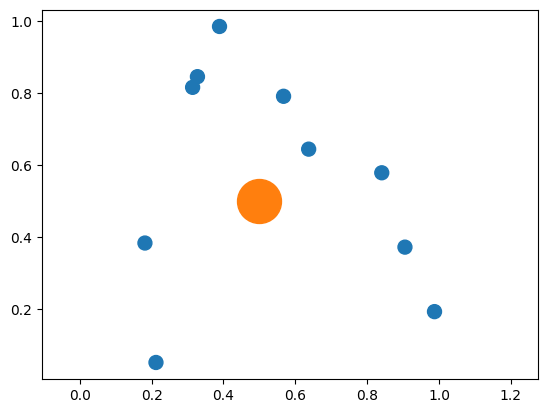

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.axis("equal")
plt.scatter(
    position[0,:].cpu(),  # Don't forget .cpu()
    position[1,:].cpu(),
    s=mass.cpu()
)

sun_pos = (0.5, 0.5)

plt.scatter(
  sun_pos[0],
  sun_pos[1],
  s=1000,
)

plt.show()

Now, we define a function that computes the forces between each planets and the sum 

In [13]:
def calculate_forces(pos, mass):
    diffx = sun_pos[0] - pos[0] # Scalar - Tensor
    diffy = sun_pos[1] - pos[1]
    diff = torch.stack([diffx, diffy]) # shape: (2, N)
    distance = diff.norm(dim=0) # length: N
    direction = diff / distance # 
    magnitude = G * mass / distance**2
    forces = magnitude * direction
    return forces

We can plot the forces using `quiver`

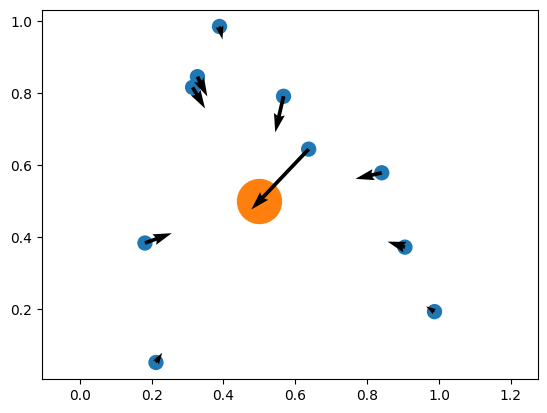

In [14]:
import matplotlib.pyplot as plt

plt.axis("equal")
plt.scatter(
    position[0,:].cpu(),
    position[1,:].cpu(),
    s=mass.cpu()
)

plt.scatter(
  sun_pos[0],
  sun_pos[1],
  s=1000,
)

forces = calculate_forces(position, mass)

plt.quiver(
  position[0,:].cpu(),
  position[1,:].cpu(),
  forces[0,:].cpu(),
  forces[1,:].cpu()
)

# Comparison between NumPy, CuPy and PyTorch

Let measure the time of our function with and without `@torch.compile` to compare the performance.

In [15]:
%load_ext cupyx.profiler

/home/sheldens/.local/lib/python3.13/site-packages/cupy/_environment.py:663: UserWarning: 
--------------------------------------------------------------------------------

  CuPy may not function correctly because multiple CuPy packages are installed
  in your environment:

    cupy, cupy-cuda12x

  Follow these steps to resolve this issue:

    1. For all packages listed above, run the following command to remove all
       existing CuPy installations:

         $ pip uninstall <package_name>

      If you previously installed CuPy via conda, also run the following:

         $ conda uninstall cupy

    2. Install the appropriate CuPy package.
       Refer to the Installation Guide for detailed instructions.

         https://docs.cupy.dev/en/stable/install.html

--------------------------------------------------------------------------------

  warnings.warn(f'''


In [16]:
# Finally, compute it using pytorch
n = 10_000_000
pos = torch.rand(2, n, device=device)
mass = torch.rand(n, device=device)

%gpu_timeit calculate_forces(pos, mass)

run                 :    CPU:   178.377 us   +/-  5.961 (min:   171.937 / max:   456.949) us     GPU-0:   935.555 us   +/- 24.510 (min:   907.264 / max:  1741.824) us


In [17]:
# We can use torch.compile to speed things up!
n = 10_000_000
pos = torch.rand(2, n, device=device)
mass = torch.rand(n, device=device)

@torch.compile
def calculate_forces_fast(pos, mass):
    return calculate_forces(pos, mass)

forces = calculate_forces_fast(pos, mass);

%gpu_timeit -n50 calculate_forces_fast(pos, mass)

run                 :    CPU:   117.696 us   +/-  3.774 (min:   112.661 / max:   137.016) us     GPU-0:   327.004 us   +/-  0.727 (min:   325.632 / max:   329.728) us


In [ ]:
# Finally, compute it using pytorch on the CPU
n = 10_000_000
pos = torch.rand(2, n, device="cpu")
mass = torch.rand(n, device="cpu")

%gpu_timeit calculate_forces(pos, mass)

## Exercise

Implement the same function in NumPy or CuPy (pick one of the two) and compare the performance to PyTorch. What is the difference. Why do you think this is the case? 

In [ ]:
# Next, compute it using Cupy
import cupy

n = 10_000_000
pos = cupy.random.rand(2, n)
mass = cupy.random.rand(n)

def calculate_forces_cupy(pos, mass):
    diffx = sun_pos[0] - pos[0] 
    diffy = sun_pos[1] - pos[1]
    diff = cupy.stack([diffx, diffy]) 
    distance = cupy.linalg.norm(diff, axis=0) 
    direction = diff / distance 
    magnitude = G * mass / distance**2
    return magnitude * direction

%gpu_timeit -n 10 calculate_forces_cupy(pos, mass)

In [ ]:
# First, compute it using NumPy
import numpy as np

n = 10_000_000
pos = np.random.rand(2, n)
mass = np.random.rand(n)

def calculate_forces_numpy(pos, mass):
    diffx = sun_pos[0] - pos[0] 
    diffy = sun_pos[1] - pos[1]
    diff = np.stack([diffx, diffy]) # Different
    distance = np.linalg.norm(diff, axis=0) # Different
    direction = diff / distance 
    magnitude = G * mass / distance**2
    return magnitude * direction

%timeit -n1 calculate_forces_numpy(pos, mass)

# Autodiff (gradients, derivatives) [only if there is time]

A special feature of PyTorch is the ability to automatically calculate the derivative of functions. In this example, we see that for `x=5` we get `f(x)=25` and `df(x)/dx=10`

In [ ]:
# Print the input
x = torch.tensor(5.0, device=device, requires_grad=True)
print(f"{x=}")

# Define our function
def f(x):
    return x**2

# Print the output
y = f(x)
print(f"{y=}")

# Print the derivative dy/dx
y.backward()
print(f"{x.grad=}")

In [ ]:
# Print the input
x = torch.rand(10, device=device, requires_grad=True)
print(f"{x=}")

# Print the output
y = torch.sum(torch.sqrt(x) ** torch.sin(x))
print(f"{y=}")

# Print the derivative dy/dx for each x[i]
y.backward()
print(f"{x.grad=}")